# 0. DATASET CONTEXT

It was obtained from [Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

The objective of this notebook is use an unsupervised model to predict the variable ``poisonous`` of the mushroom which is binary (edible or poisonous) and compare it to a supervised one.


The columns that exists in this dataset are:

- classes: edible=e, poisonous=p

- cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

- cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

- cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

- bruises: bruises=t,no=f

- odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

- gill-attachment: attached=a,descending=d,free=f,notched=n

- gill-spacing: close=c,crowded=w,distant=d

- gill-size: broad=b,narrow=n

- gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

- stalk-shape: enlarging=e,tapering=t

- stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

- stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

- stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

- stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- veil-type: partial=p,universal=u

- veil-color: brown=n,orange=o,white=w,yellow=y

- ring-number: none=n,one=o,two=t

- ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

- spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

- population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

- habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

# 1. NECESSARY LIBRARIES

In [1]:
# Essentials libraries
print('●Importing essential libraries●')
try:
    import pandas as pd #data manipulation
    pd.set_option('display.max_columns', None) #forcing pandas to show all columns
    import missingno as msno #missing values visualization
    import numpy as np #data operations
    import seaborn as sns #data visualization
    import matplotlib.pyplot as plt #interactive visualizations
    import plotly.express as px #3D visualization
    from pathlib import Path #file path
    
    from scipy.stats import chi2_contingency #cramer's v matrix


    from sklearn.cluster import KMeans #clustering model
    from sklearn.model_selection import train_test_split #split
    from sklearn.decomposition import PCA #PCA
    from sklearn.ensemble import RandomForestClassifier #classification model
    from sklearn.metrics import accuracy_score #accuracy
    from sklearn.impute import KNNImputer #imputation
    from sklearn.preprocessing import OrdinalEncoder
    print('✅ Essentials libraries are imported')
except ImportError as e:
    print(f'❌ Error importing libraries: {e}')



●Importing essential libraries●
✅ Essentials libraries are imported


# 2. DATASET LOAD

In [2]:
#Dataset loading
print('●●●Loading dataset...')
df = pd.read_csv(Path('../data/data_raw/mushrooms.csv'))
print ('✅ Dataset loaded')

●●●Loading dataset...
✅ Dataset loaded


In [3]:
#We make sure it is a dataframe.
print('●●●Making sure dataset is a DataFrame...')
df = pd.DataFrame(df)
print('✅ Dataset is a DataFrame')

●●●Making sure dataset is a DataFrame...
✅ Dataset is a DataFrame


# 3. DATASET COPY

In [4]:
#A copy is made to avoid losing data in the original file.
print('●●●Copying dataset...')
df_copy = df.copy()
print('✅ Dataset copied')

●●●Copying dataset...
✅ Dataset copied


# 4. CLEANING

### 4.1. DATA OVERVIEW

In [5]:
#First rows of the dataset
print('First rows of the dataset')
print(('=')*26)
df_copy.head()

First rows of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [6]:
#Last rows of the dataset
print('Last rows of the dataset')
print(('=')*25)
df_copy.tail()

Last rows of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,o,c,l


In [7]:
#General info of the dataset
print('General info of the dataset')
print(('=')*28)
df_copy.info()

General info of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring 

In [8]:
#Type of the columns is changed to 'category'
print('●●●Changing type of columns to category...')
for col in df_copy.columns:
    df_copy[col] = df_copy[col].astype('category')
df_copy.info()
print('✅ Type of columns changed to category')

●●●Changing type of columns to category...
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   class                     8124 non-null   category
 1   cap-shape                 8124 non-null   category
 2   cap-surface               8124 non-null   category
 3   cap-color                 8124 non-null   category
 4   bruises                   8124 non-null   category
 5   odor                      8124 non-null   category
 6   gill-attachment           8124 non-null   category
 7   gill-spacing              8124 non-null   category
 8   gill-size                 8124 non-null   category
 9   gill-color                8124 non-null   category
 10  stalk-shape               8124 non-null   category
 11  stalk-root                8124 non-null   category
 12  stalk-surface-above-ring  8124 non-null   category
 13  stalk-surface-be

In [9]:
#Basic statistics of the dataset
print('Basic statistics of the dataset')
print(('=')*32)
df_copy.describe(include='all') #numeric and categorical variables

Basic statistics of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### 4.2. NULL VALUES

With .info we could see there is no nulls, but we'll visualize there is no nulls.

Missing values visualization


<Axes: >

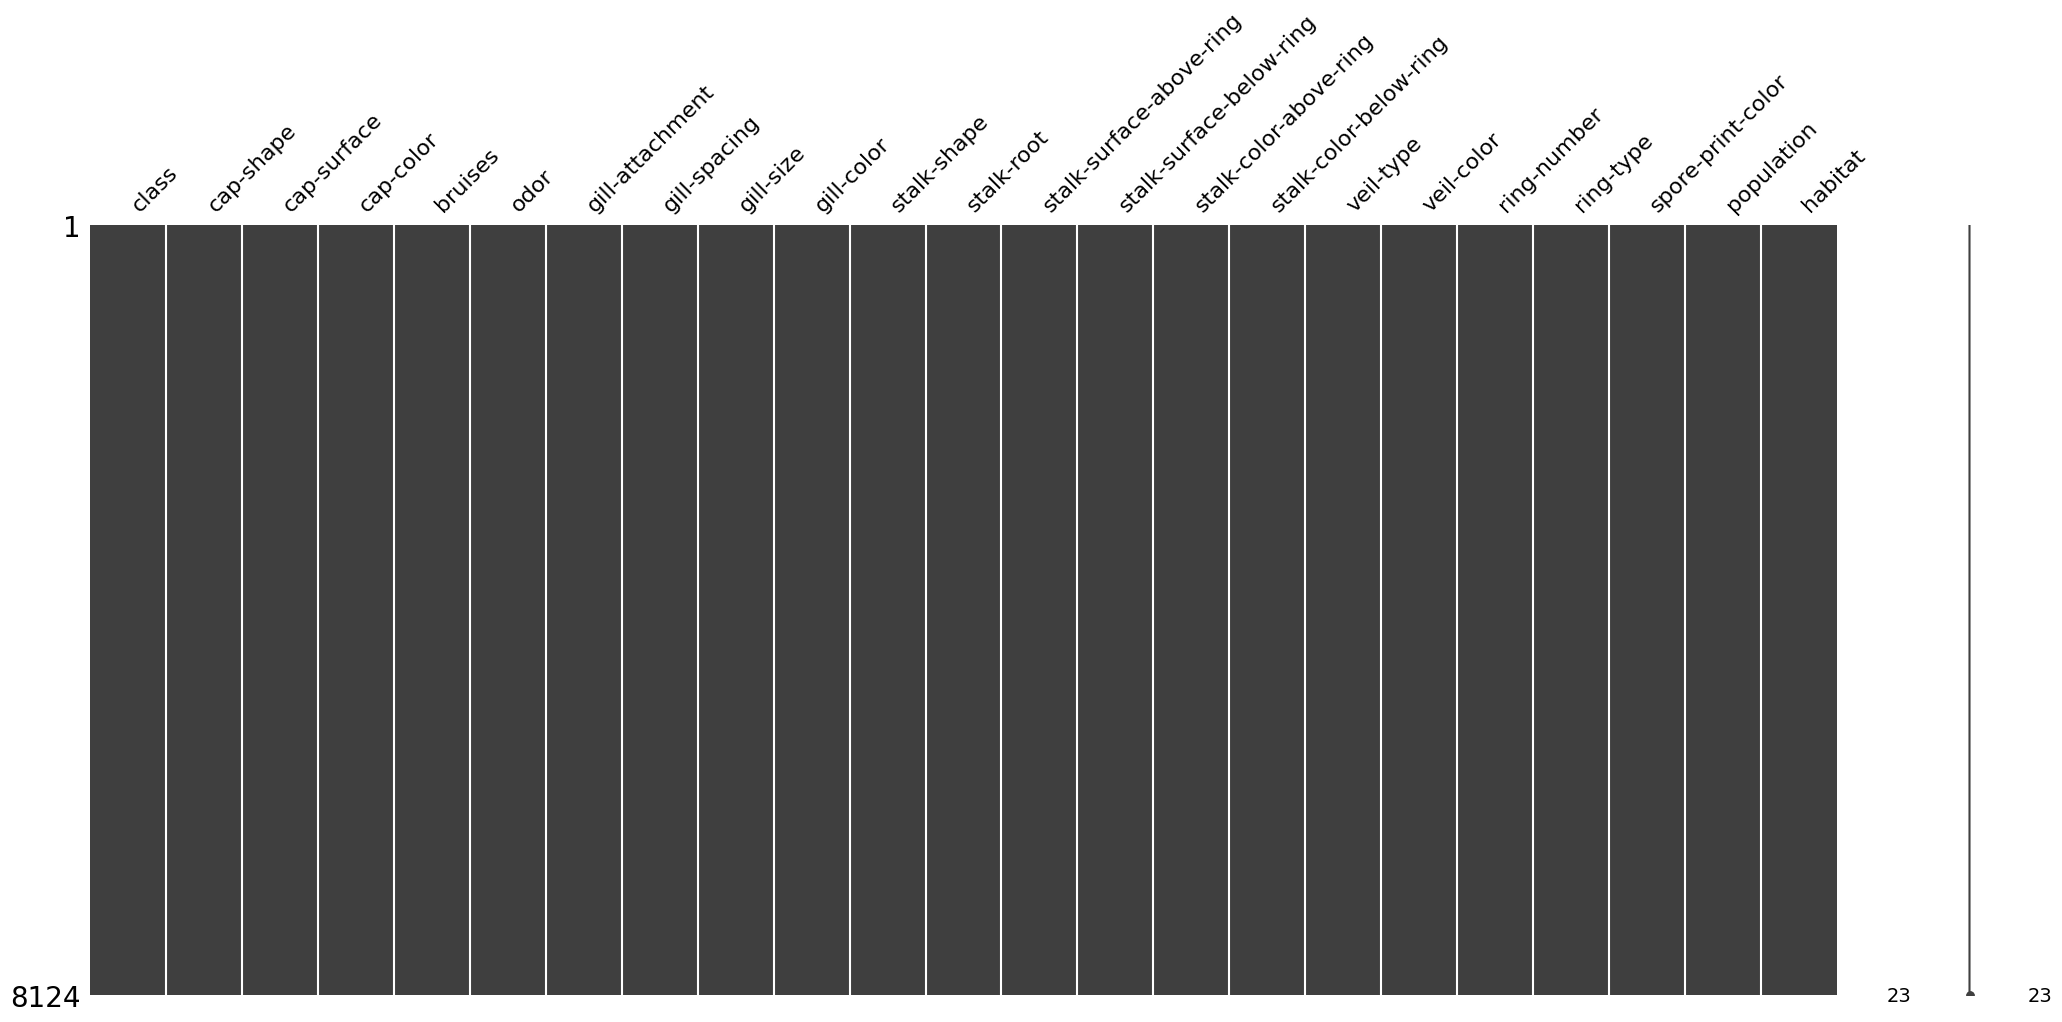

In [10]:
print('Missing values visualization')
print(('=')*29)
msno.matrix(df_copy)

We'll look for strange values in the columns, so we look for unique values.

In [11]:
#Dataframe with features and unique values.
print('Dataframe with features and unique values')
print(('=')*42)
feature = df_copy.columns
n_values = df_copy.nunique().values

dataframe_feature_nvalues = pd.DataFrame({
    "feature": feature,
    "n_values": n_values
})

display(dataframe_feature_nvalues)

Dataframe with features and unique values


,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


In the the context and with this dataframe we know the unique values in every column and their meaning, now we'll quantify how many are in each category.

In [12]:
print('Unique values of each column')
print(('=')*30)
for col in df_copy.columns:
    print(('_')*30 )
    print(df_copy[col].value_counts())


Unique values of each column
______________________________
class
e    4208
p    3916
Name: count, dtype: int64
______________________________
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
______________________________
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
______________________________
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
r      16
u      16
Name: count, dtype: int64
______________________________
bruises
f    4748
t    3376
Name: count, dtype: int64
______________________________
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
______________________________
gill-attachment
f    7914
a     210
Name: count, dtype: int64
______________________________
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
______________________________
gill-size
b    5612
n    2512
Name

The only strange thing here is the '?' variable in 'stalk-root' and that 'veil-type' has only one category so we'll impute the '?' values with KNN and will drop the 'stalk-root' column.

In [13]:
#Dropping 'veil-type' column.
print(f"Dataset BEFORE dropping 'veil-type' has {len(df_copy.columns)} columns")
print("✂ Dropping 'veil-type' column")
df_copy.drop('veil-type', axis=1, inplace=True) #axis=1 means columns, axis =0 means rows.
print(f"Dataset AFTER dropping 'veil-type' has {len(df_copy.columns)} columns")
print('✅ Veil-type column dropped')

Dataset BEFORE dropping 'veil-type' has 23 columns
✂ Dropping 'veil-type' column
Dataset AFTER dropping 'veil-type' has 22 columns
✅ Veil-type column dropped


Steps to imputing "?" category in "stalk-root" column


1. Replacing "?" with NaN
**************************
Unique values of "stalk-root" column BEFORE replacement: ['e', 'c', 'b', 'r', '?']
Categories (5, str): ['?', 'b', 'c', 'e', 'r']
Unique values of "stalk-root" column AFTER replacement: ['e', 'c', 'b', 'r', NaN]
Categories (5, str): ['?', 'b', 'c', 'e', 'r']
 ✅ "?" category replaced with NaN


Missing values visualization after replacing "?" with NaN
NaN count: 2480 (30.5% of data)
Axes(0.125,0.11;0.698618x0.77)


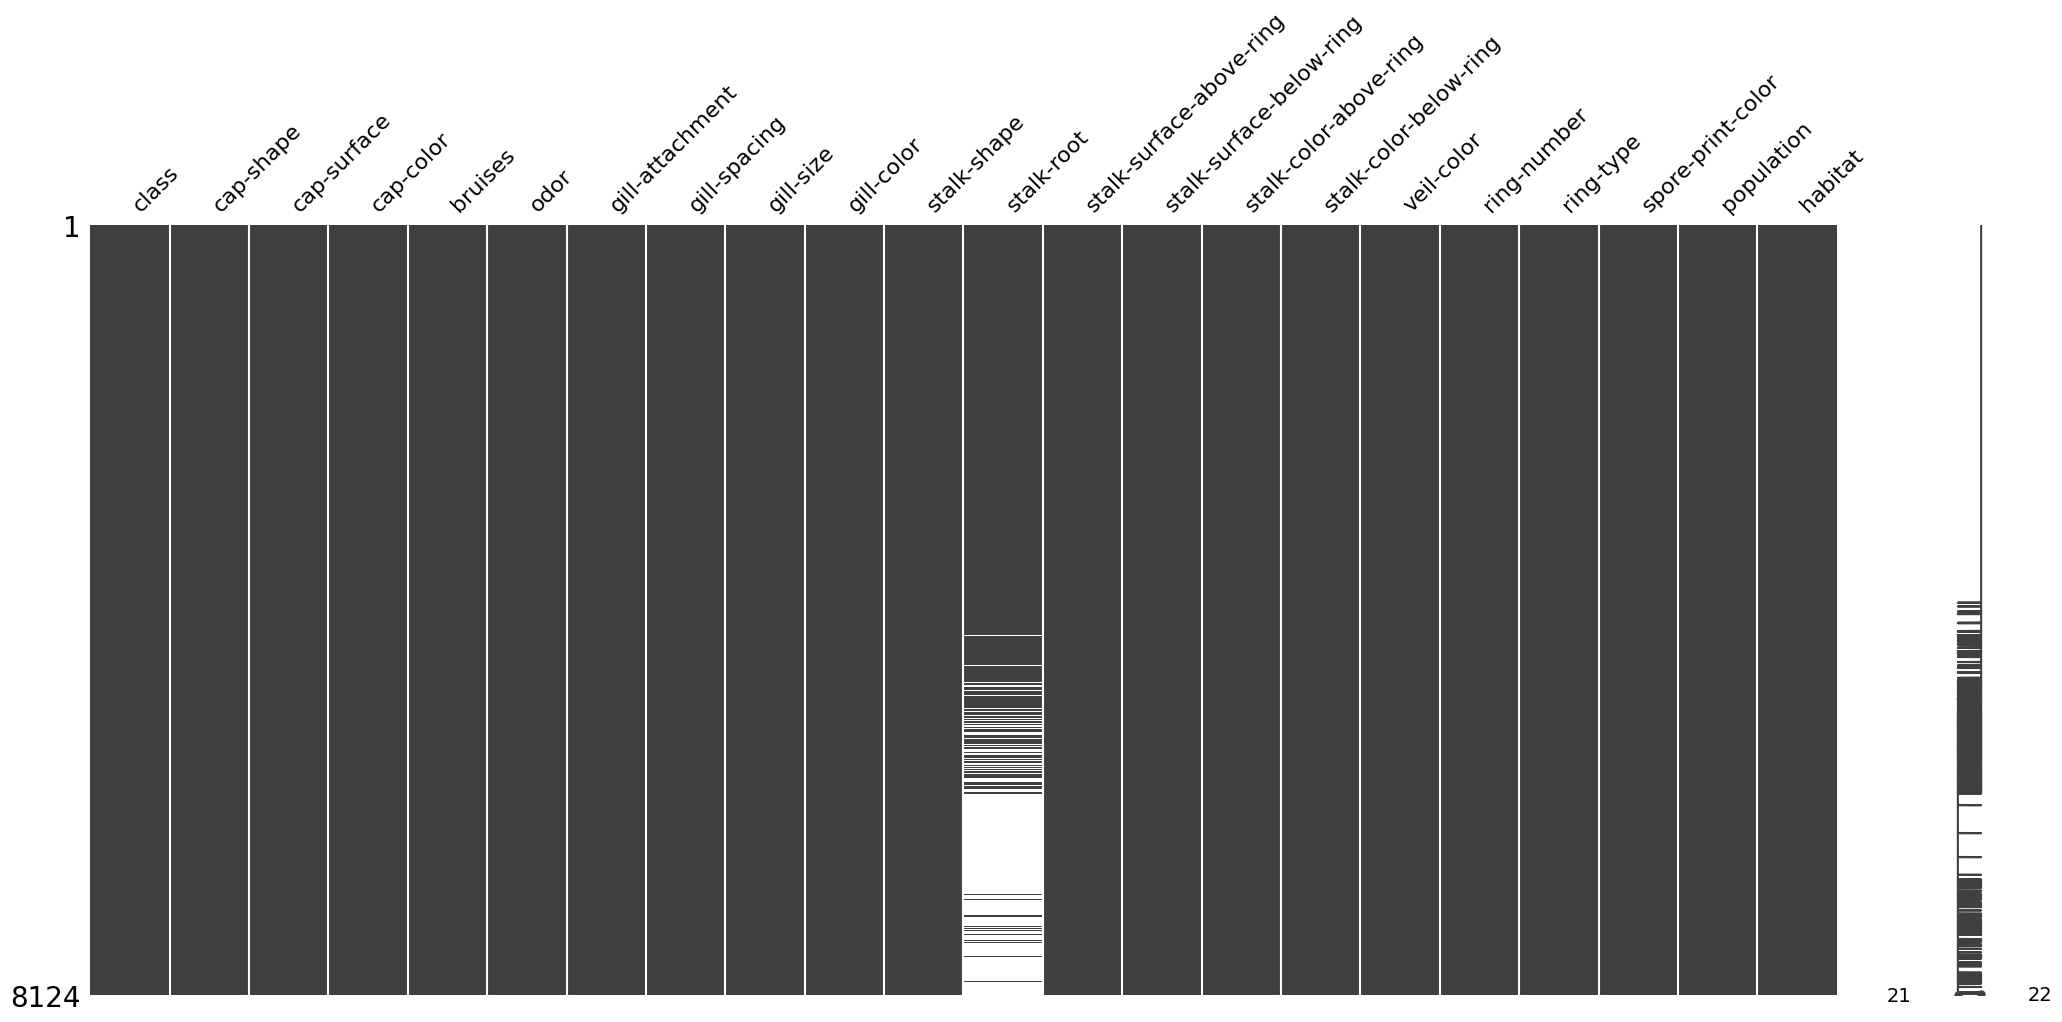

In [14]:
#Imputing '?' category in 'stalk-root' column with KNN.
print('Steps to imputing "?" category in "stalk-root" column')
print(('=')*55) #It works with () or witout them.
print('\n')

print('1. Replacing "?" with NaN')
print('*'*26)
print(f'Unique values of "stalk-root" column BEFORE replacement: {df_copy["stalk-root"].unique()}')
df_copy['stalk-root'] = df_copy['stalk-root'].replace('?', np.nan)
print(f'Unique values of "stalk-root" column AFTER replacement: {df_copy["stalk-root"].unique()}')
print(' ✅ "?" category replaced with NaN')
print('\n')

nullsreplaced = msno.matrix(df_copy)
print('Missing values visualization after replacing "?" with NaN')
print(('=')*59)
print(f'NaN count: {df_copy["stalk-root"].isna().sum()} ({df_copy["stalk-root"].isna().mean()*100:.1f}% of data)')
print(nullsreplaced)


In [15]:
print('2. Ordinal Encoding DataFrame (KNN needs numeric values)')
print('*'*57)
encoder = OrdinalEncoder() #OrdinalEncoder 
df_encoded_ord = pd.DataFrame(
    encoder.fit_transform(df_copy),
    columns=df_copy.columns
)
print(f'Shape: {df_encoded_ord.shape}')
print(df_encoded_ord.head())
print('✅ DataFrame ordinal encoded')
print('\n')



2. Ordinal Encoding DataFrame (KNN needs numeric values)
*********************************************************
Shape: (8124, 22)
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0    1.0        5.0          2.0        4.0      1.0   6.0              1.0   
1    0.0        5.0          2.0        9.0      1.0   0.0              1.0   
2    0.0        0.0          2.0        8.0      1.0   3.0              1.0   
3    1.0        5.0          3.0        8.0      1.0   6.0              1.0   
4    0.0        5.0          2.0        3.0      0.0   5.0              1.0   

   gill-spacing  gill-size  gill-color  stalk-shape  stalk-root  \
0           0.0        1.0         4.0          0.0         2.0   
1           0.0        0.0         4.0          0.0         1.0   
2           0.0        0.0         5.0          0.0         1.0   
3           0.0        1.0         5.0          0.0         2.0   
4           1.0        0.0         4.0          1.0      

In [16]:
print('3. Apply KNN Imputer')
print('*'*21)
print(f'NaN before KNN Imputation: {df_encoded_ord["stalk-root"].isna().sum()}')

imputer = KNNImputer(n_neighbors=5) #5 by default
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_encoded_ord),
    columns=df_copy.columns
)

print(f'NaN after KNN Imputation: {df_imputed["stalk-root"].isna().sum()}')
print('✅ KNN Imputation applied')

3. Apply KNN Imputer
*********************
NaN before KNN Imputation: 2480
NaN after KNN Imputation: 0
✅ KNN Imputation applied


Missing values visualized


<Axes: >

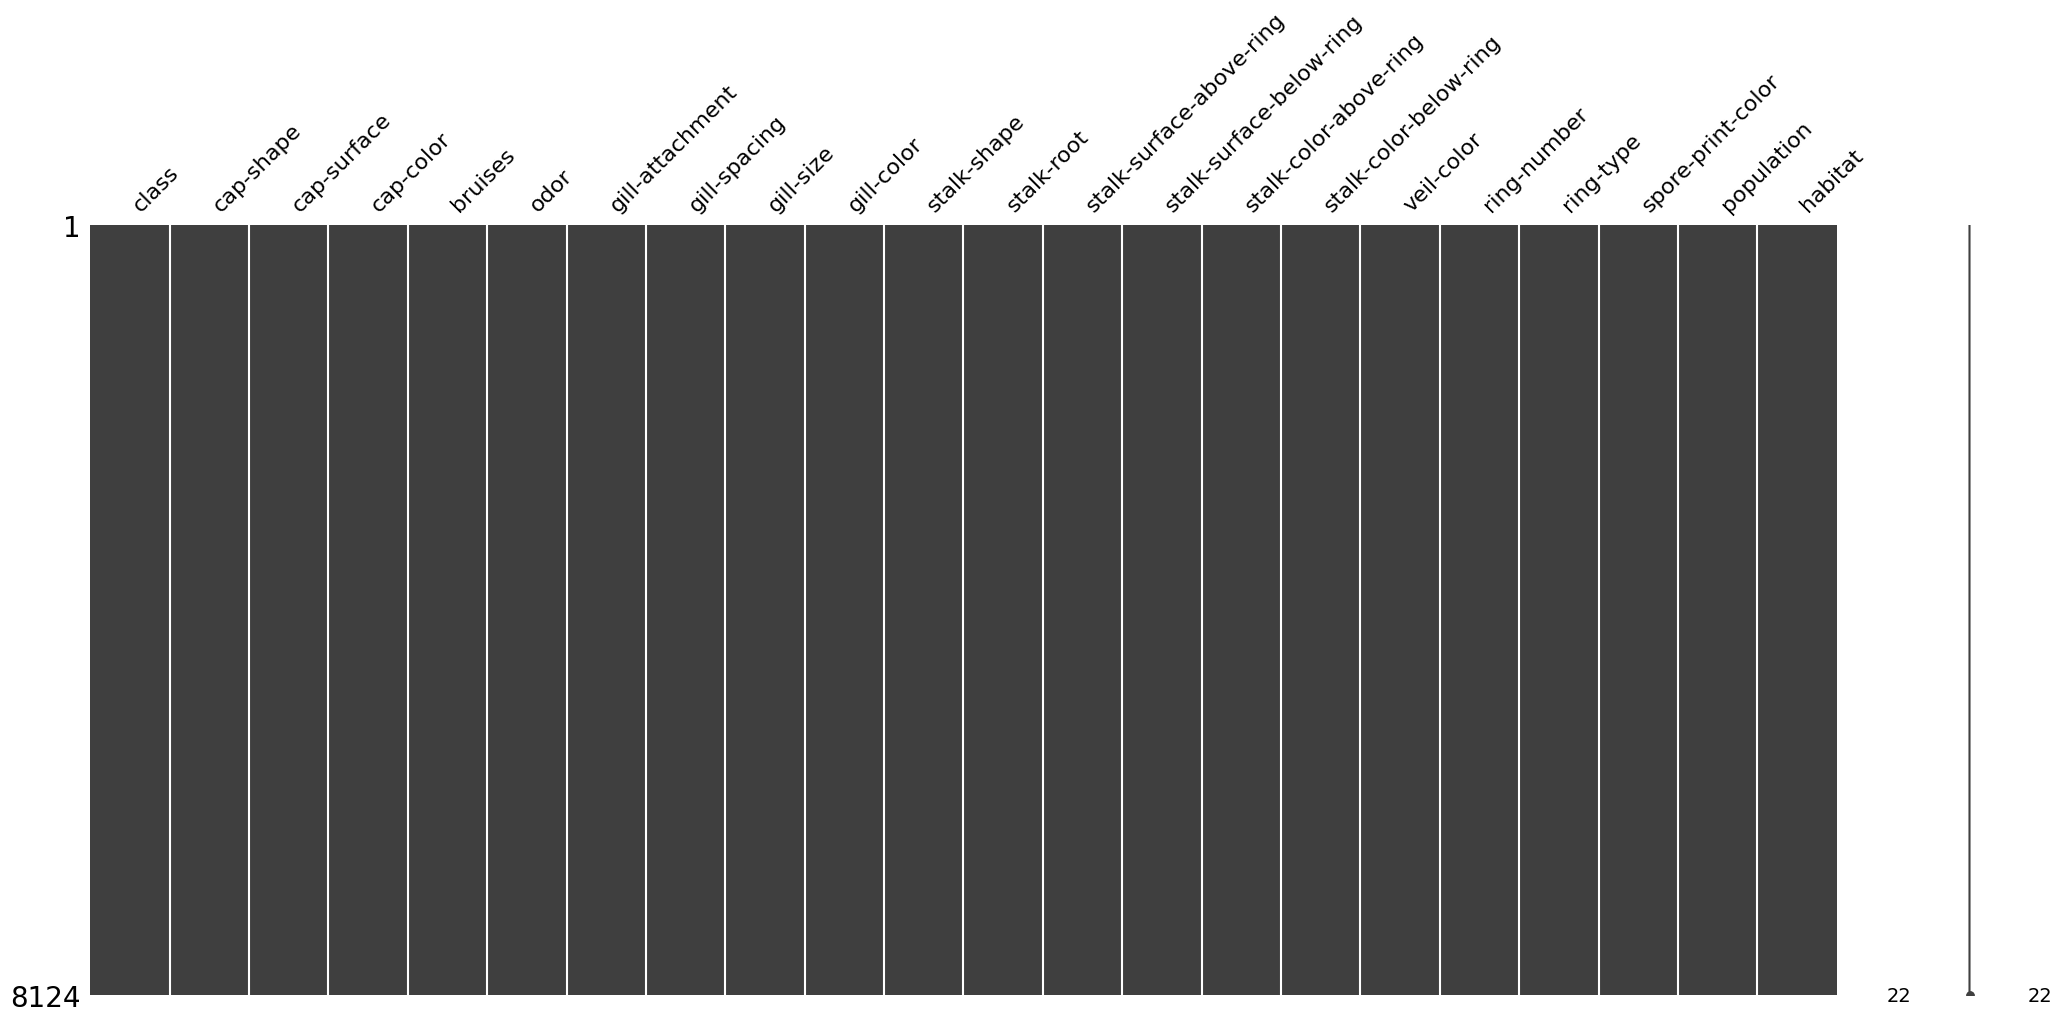

In [17]:
#Confirming there are no nan
print('Missing values visualized')
print(('=')*26)
msno.matrix(df_imputed)

In [18]:
print('4. Decoding from numeric to categorical')
print('*'*40)
df_decoded = pd.DataFrame(
    encoder.inverse_transform(np.array(df_imputed.round().copy())),
    columns=df_copy.columns
)
#Confirming there are no '?' or NaN in 'stalk-root'.
print(df_decoded['stalk-root'].value_counts())

4. Decoding from numeric to categorical
****************************************
stalk-root
b    4845
e    1752
c    1335
r     192
Name: count, dtype: int64


### 4.3. DUPLICATES

In [19]:
print('Duplicated values')
print(('=')*18)
duplicates = df_decoded.duplicated().sum()
if duplicates == 0:
    print(f'✓ There are no duplicated rows.')
else:
    print(f'✗ There are {duplicates} duplicated rows.')
    

Duplicated values
✓ There are no duplicated rows.


# 5. EXPLORATORY ANALYSIS

### 5.1. UNIVARIABLE ANALYSIS

Barplots are made to see the distribution of every category in each column. There are many where the frequency between categories is very different. In 'class', our variable to predict it is more or less equal each category (edible and poisonous).

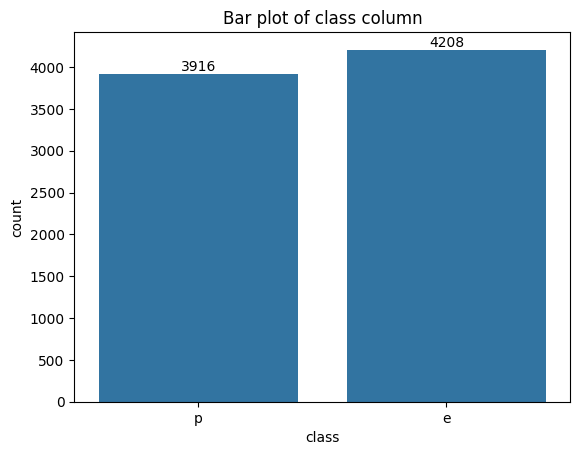

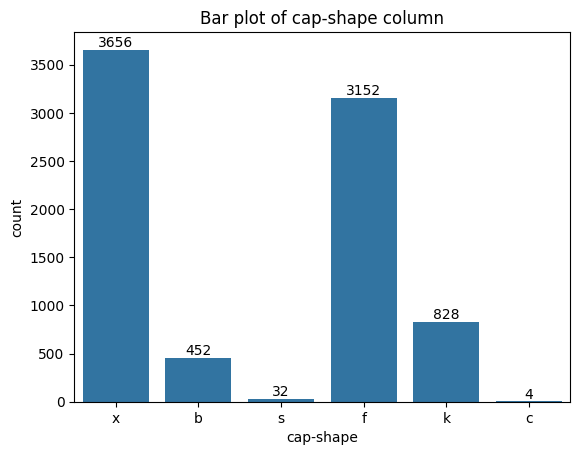

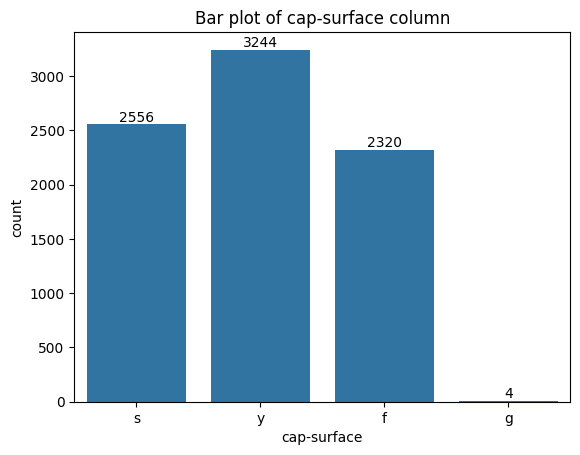

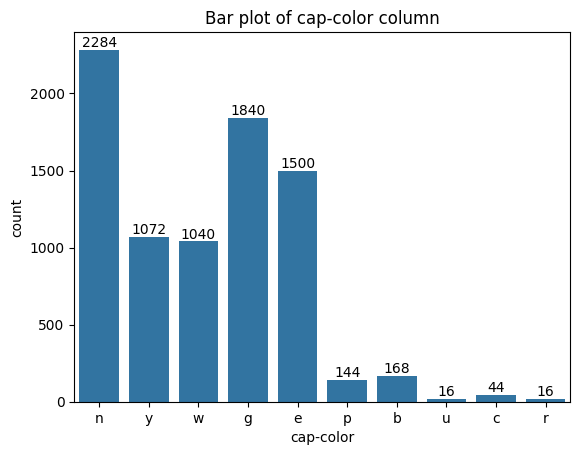

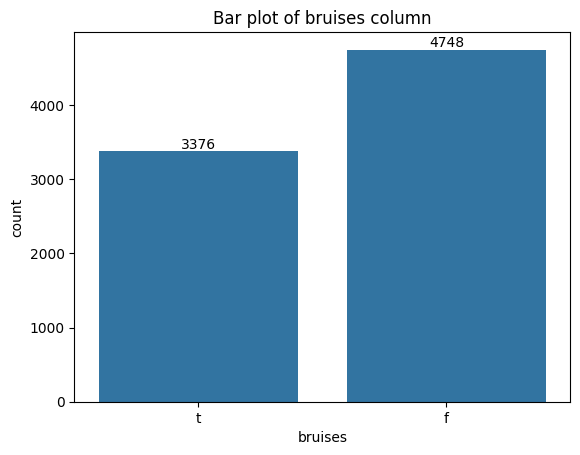

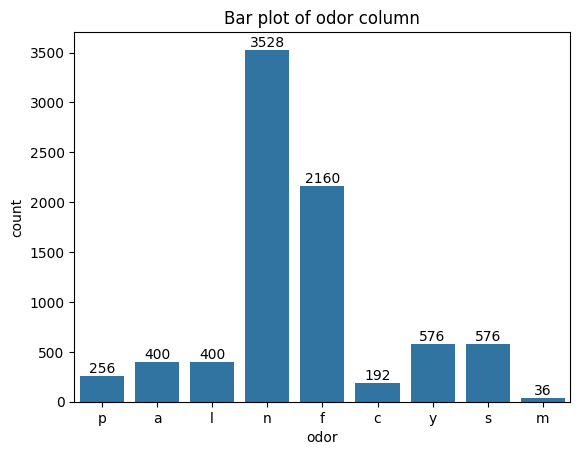

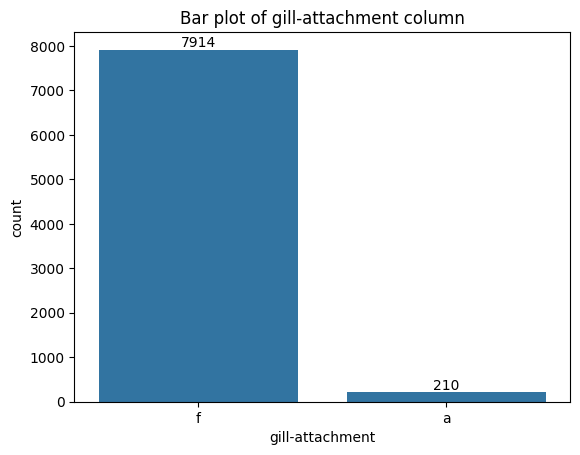

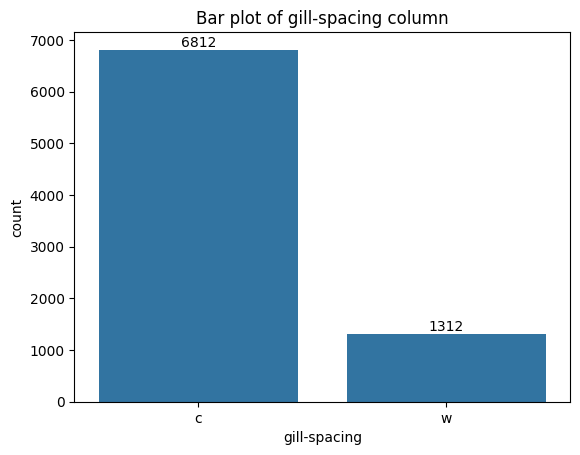

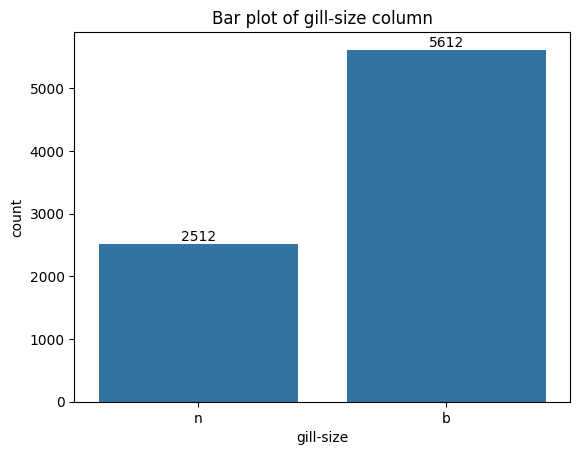

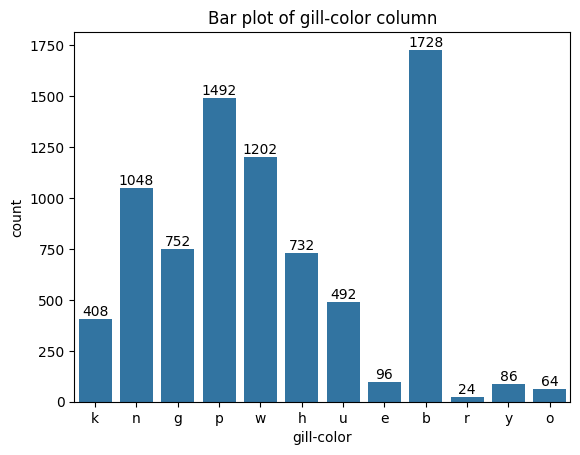

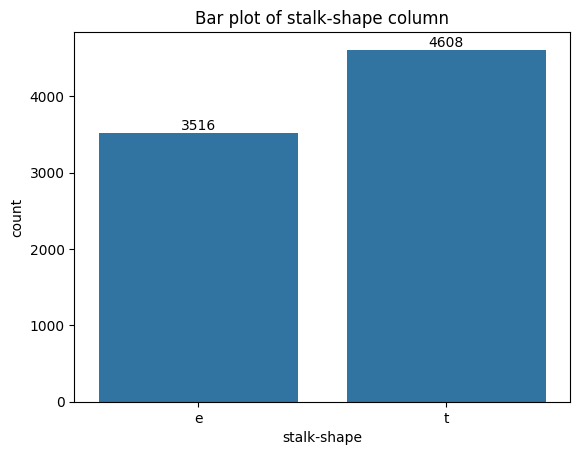

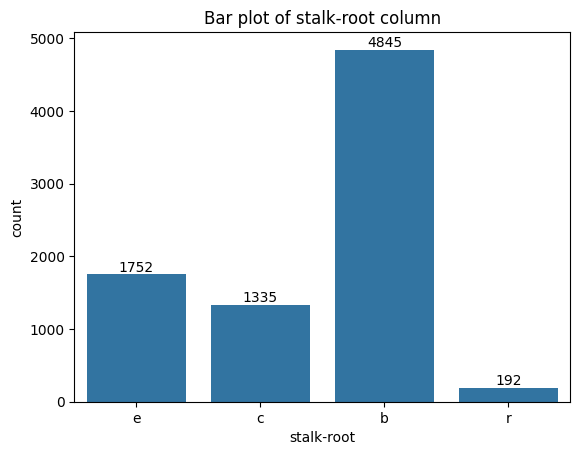

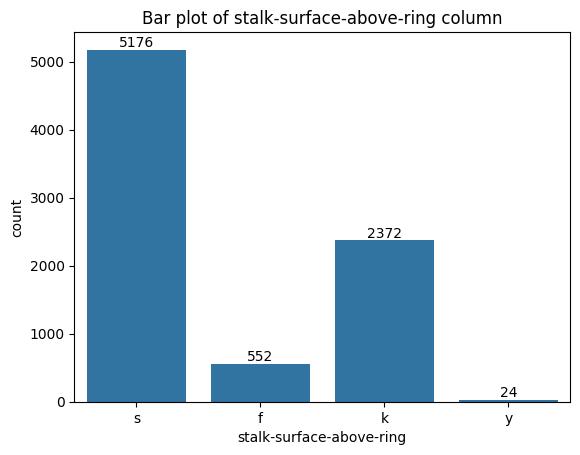

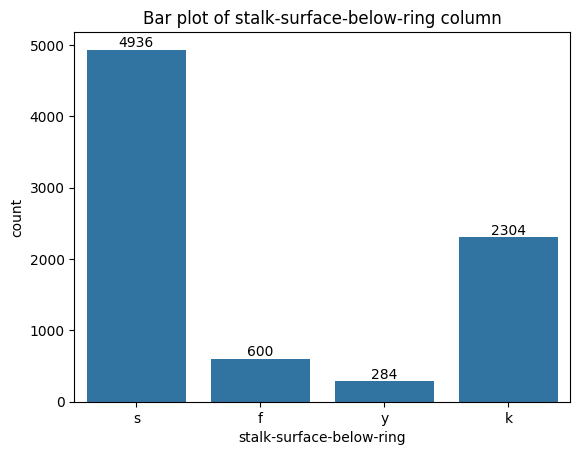

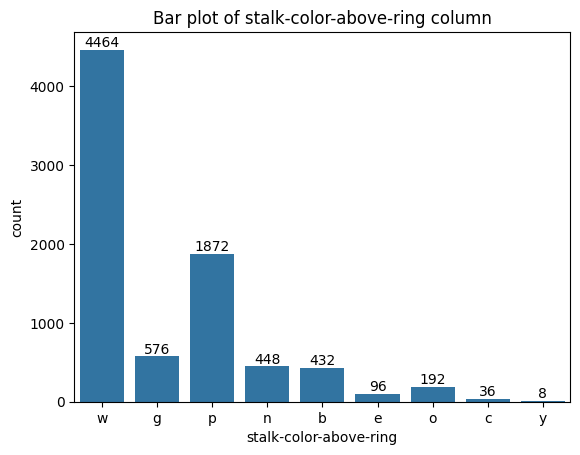

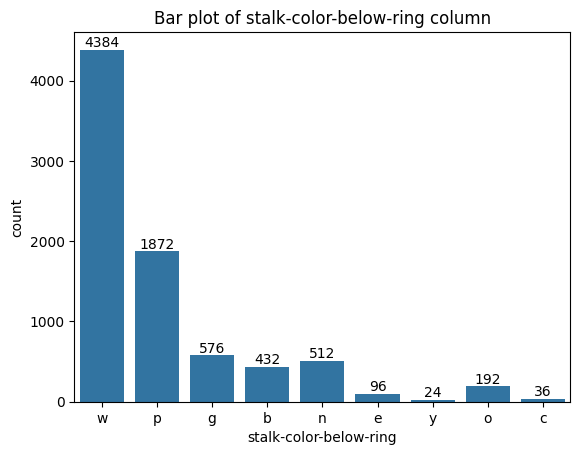

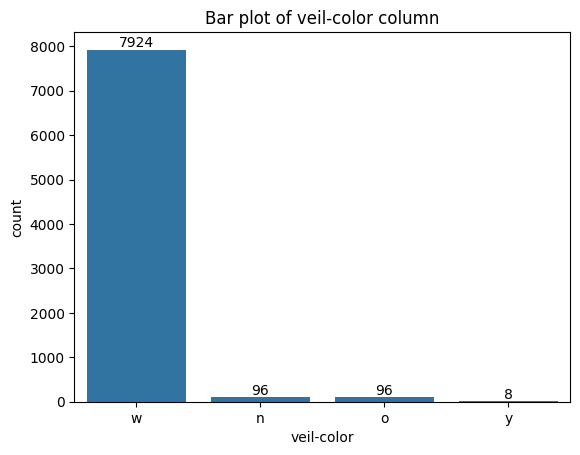

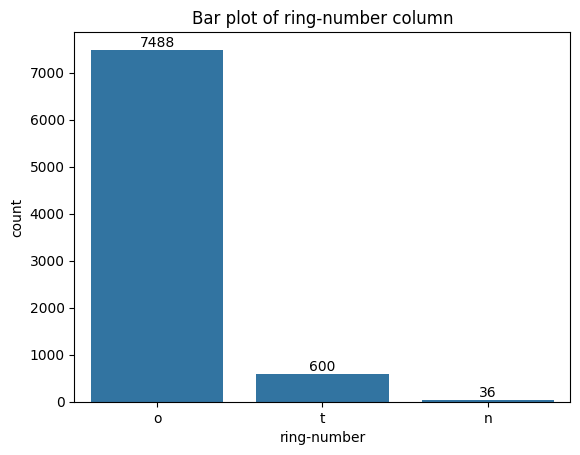

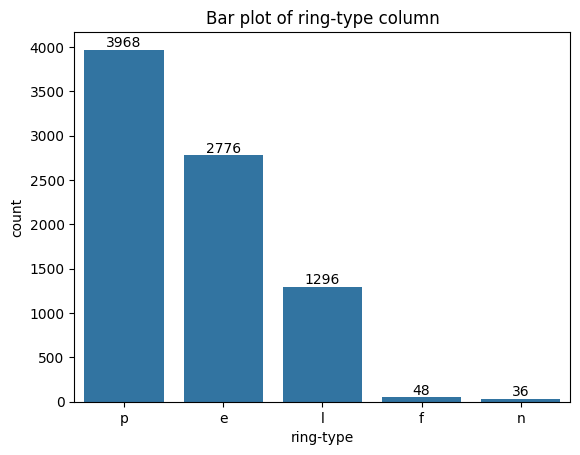

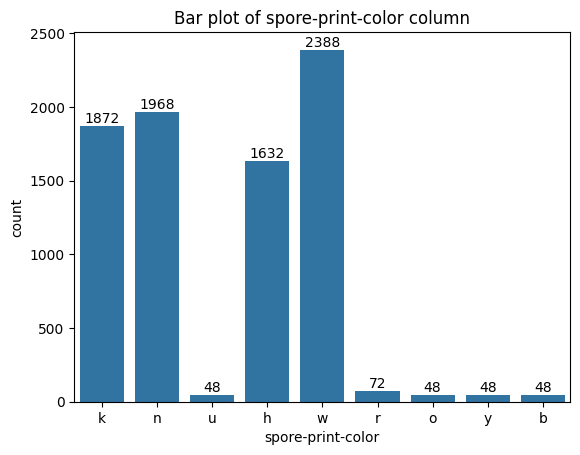

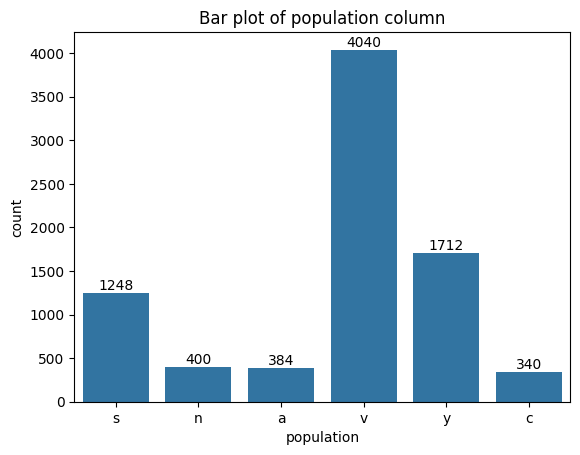

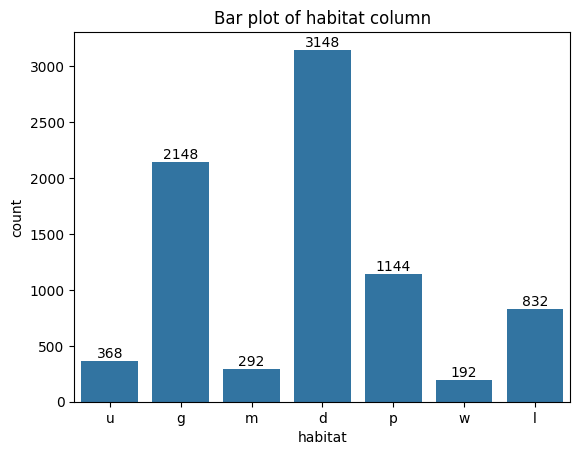

In [20]:
for col in df_decoded.columns:
    barplot = sns.countplot(x=col, data=df_decoded)
    plt.title(f'Bar plot of {col} column')
    for container in barplot.containers: 
        barplot.bar_label(container, fontsize=10) #etiquetas

    plt.show()

### 5.2. BIVARIABLE ANALYSIS

Now, we'll compare 'class' with the other columns through a table of frequencies and grouped bar plots.

In [21]:
#Relationship between 'class' and other columns.
for col in df_decoded.columns:
    if col != 'class':
        crosstab = pd.crosstab(df_decoded['class'], df_decoded[col])
        print(f'Crosstab between "class" and "{col}"')
        print(('=')*70)
        print(crosstab)
        print('\n')

Crosstab between "class" and "cap-shape"
cap-shape    b  c     f    k   s     x
class                                 
e          404  0  1596  228  32  1948
p           48  4  1556  600   0  1708


Crosstab between "class" and "cap-surface"
cap-surface     f  g     s     y
class                           
e            1560  0  1144  1504
p             760  4  1412  1740


Crosstab between "class" and "cap-color"
cap-color    b   c    e     g     n   p   r   u    w    y
class                                                    
e           48  32  624  1032  1264  56  16  16  720  400
p          120  12  876   808  1020  88   0   0  320  672


Crosstab between "class" and "bruises"
bruises     f     t
class              
e        1456  2752
p        3292   624


Crosstab between "class" and "odor"
odor     a    c     f    l   m     n    p    s    y
class                                              
e      400    0     0  400   0  3408    0    0    0
p        0  192  2160    0  36   120

We can see sometimes that 'edible' or 'poisonous' is zero in one or more category in a column. It means that this category could help a lot to predict if the mushroom is edible or poisonous. Because if the category is found in edible and poisonous it can't help to predict the 'class'.

For example, in 'ring-type', if the mushroom has ring-type 'f' (flaring) it means the mushroom is edible. If it has ring-type 'l' (large) or 'n' (none) it means the mushroom is poisonous. Meanwhile if the ring-type is 'e' (evanescent) or 'p' (pendant) it means the mushroom could be edible or poisonous.

<Figure size 800x500 with 0 Axes>

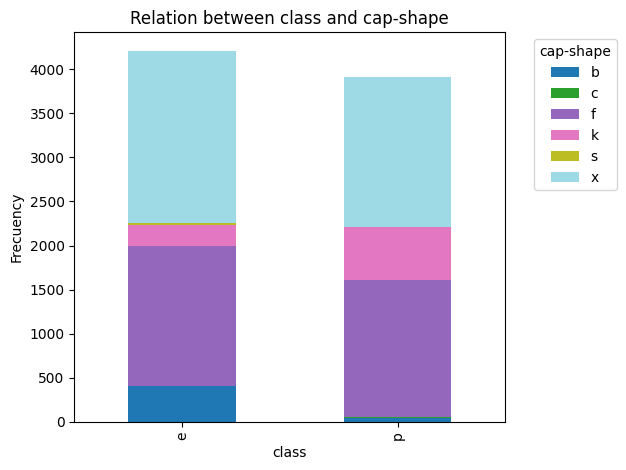

<Figure size 800x500 with 0 Axes>

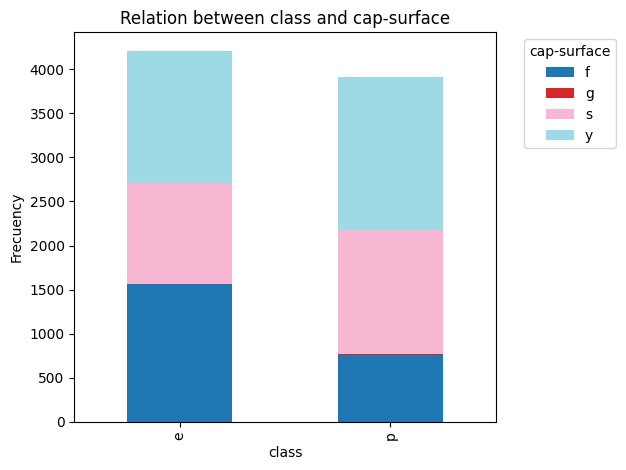

<Figure size 800x500 with 0 Axes>

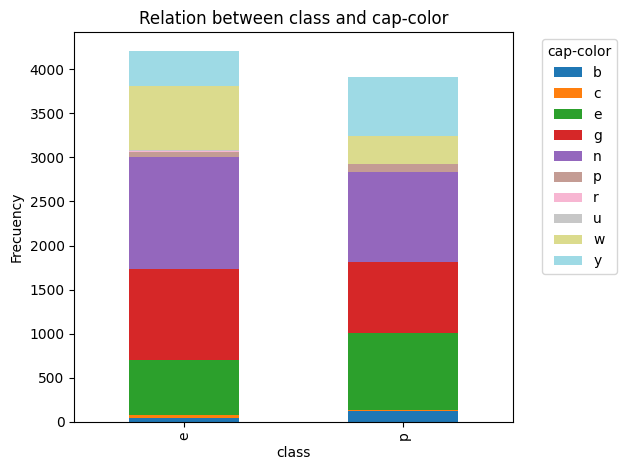

<Figure size 800x500 with 0 Axes>

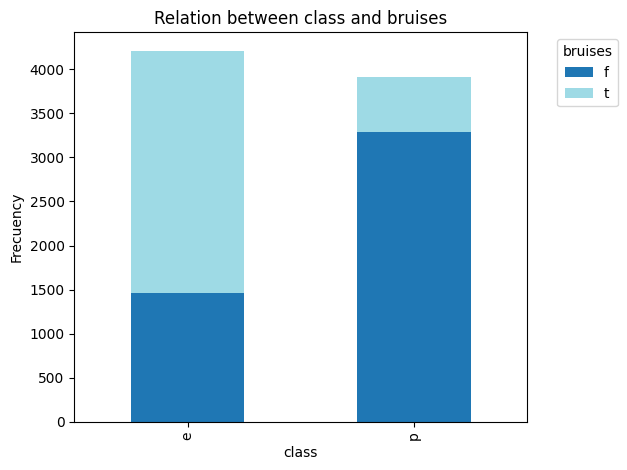

<Figure size 800x500 with 0 Axes>

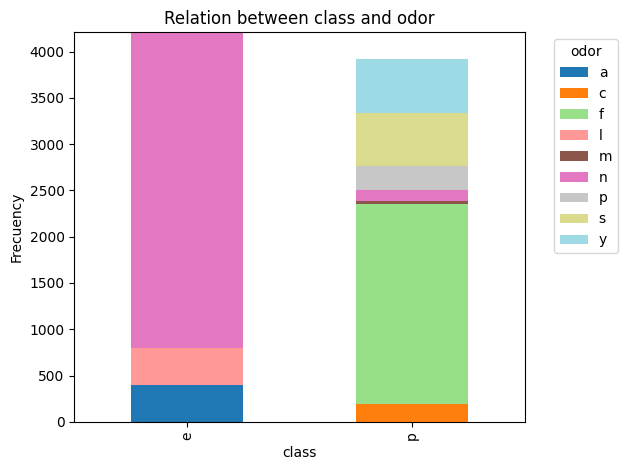

<Figure size 800x500 with 0 Axes>

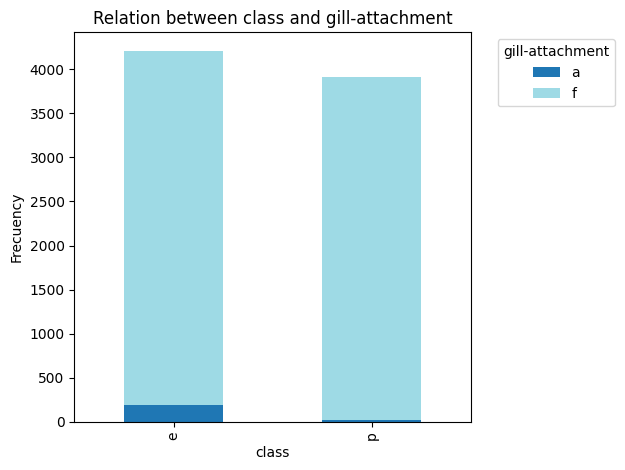

<Figure size 800x500 with 0 Axes>

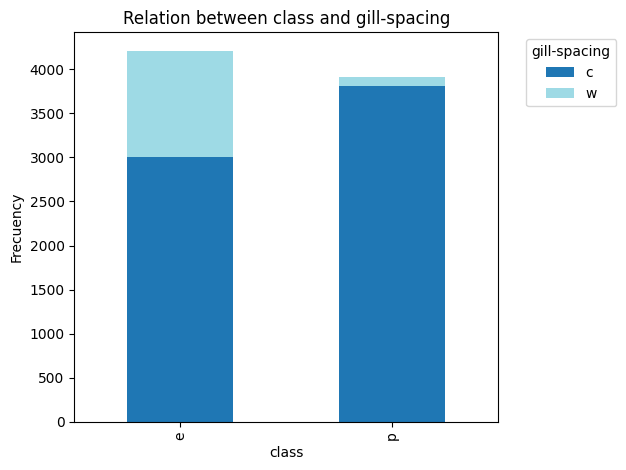

<Figure size 800x500 with 0 Axes>

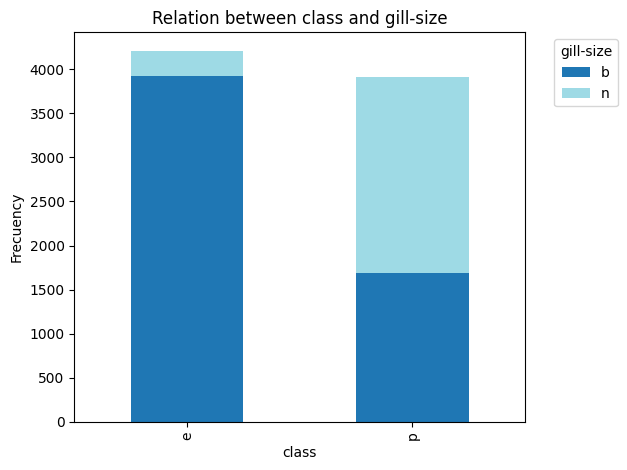

<Figure size 800x500 with 0 Axes>

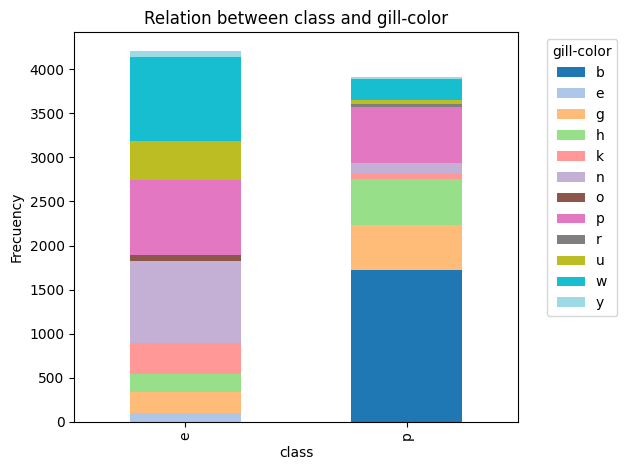

<Figure size 800x500 with 0 Axes>

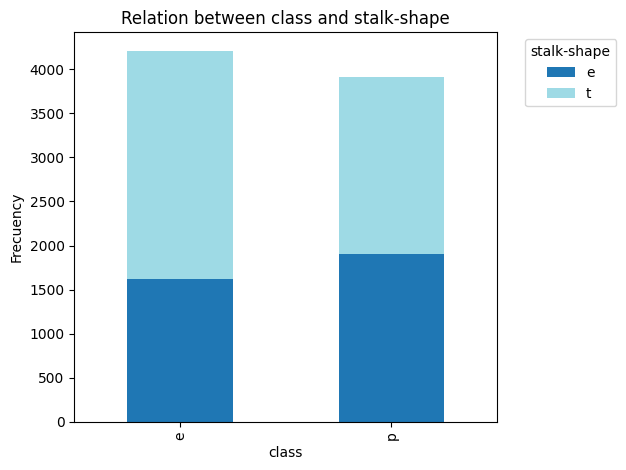

<Figure size 800x500 with 0 Axes>

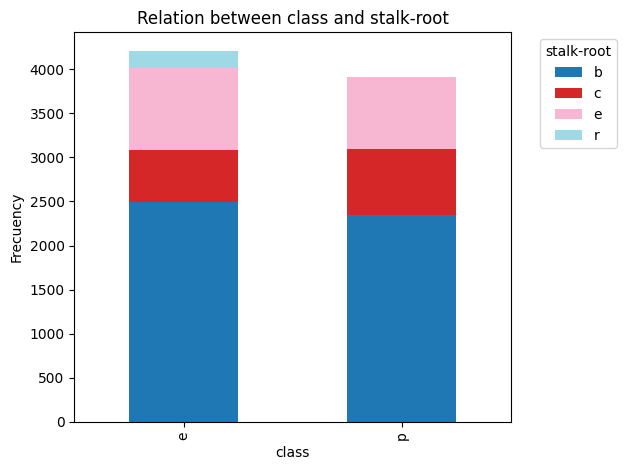

<Figure size 800x500 with 0 Axes>

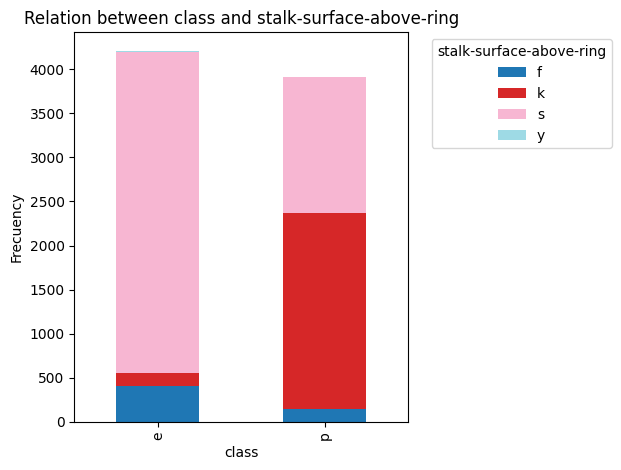

<Figure size 800x500 with 0 Axes>

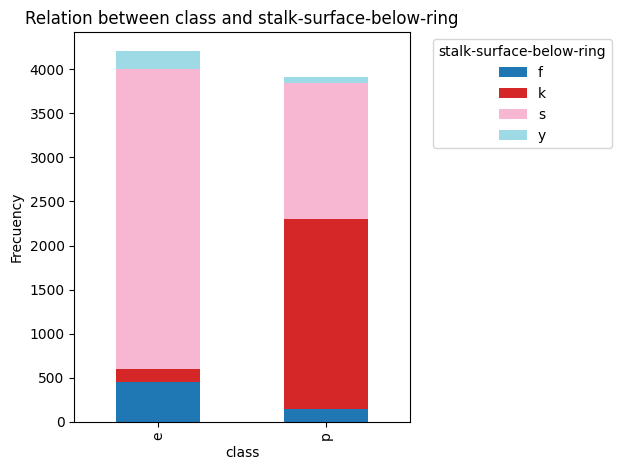

<Figure size 800x500 with 0 Axes>

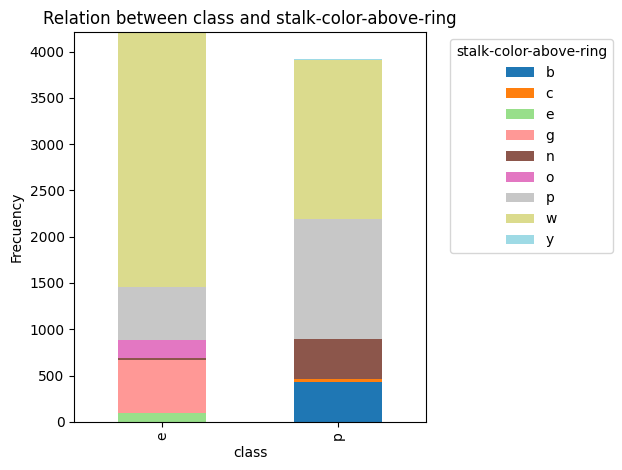

<Figure size 800x500 with 0 Axes>

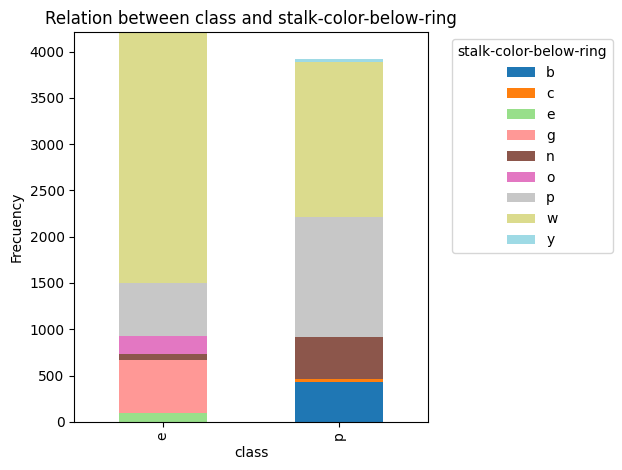

<Figure size 800x500 with 0 Axes>

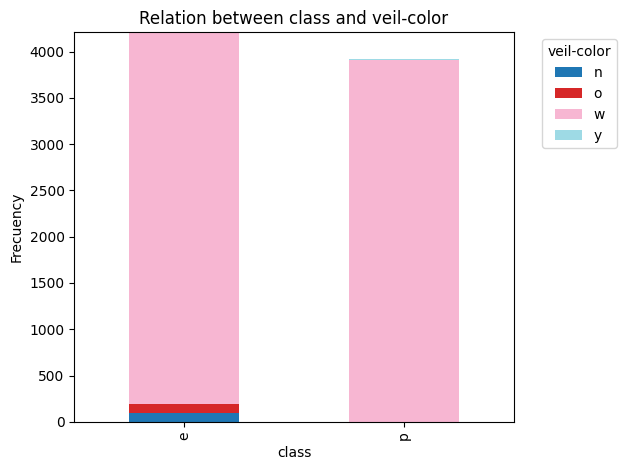

<Figure size 800x500 with 0 Axes>

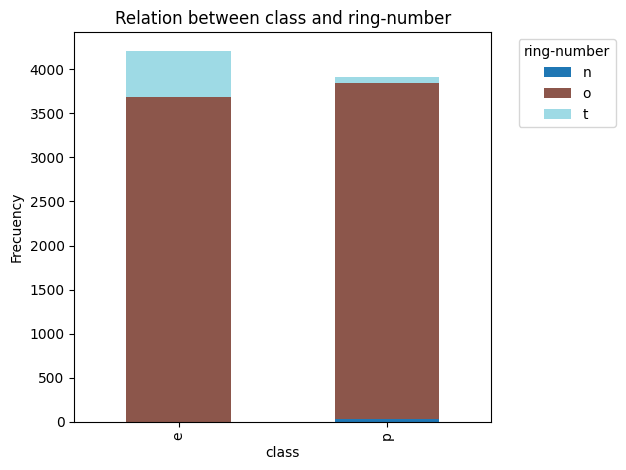

<Figure size 800x500 with 0 Axes>

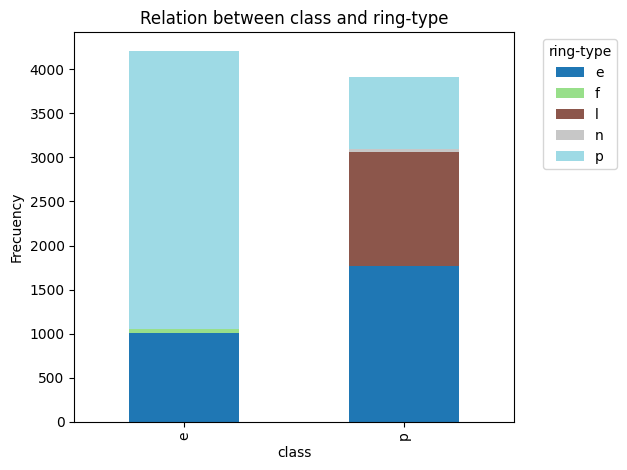

<Figure size 800x500 with 0 Axes>

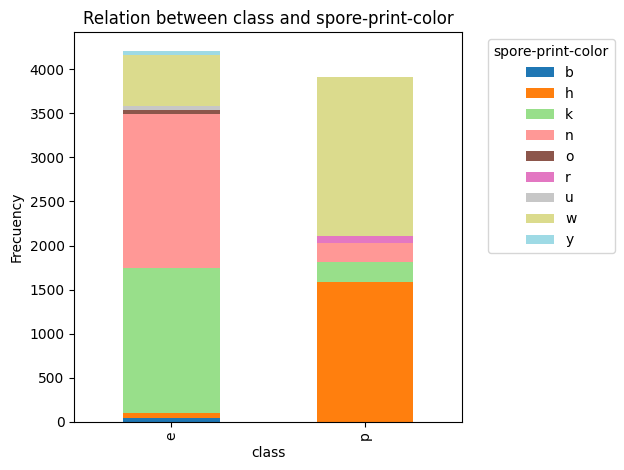

<Figure size 800x500 with 0 Axes>

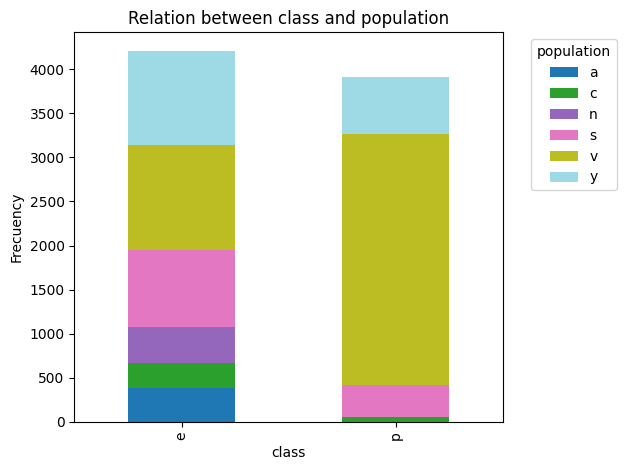

<Figure size 800x500 with 0 Axes>

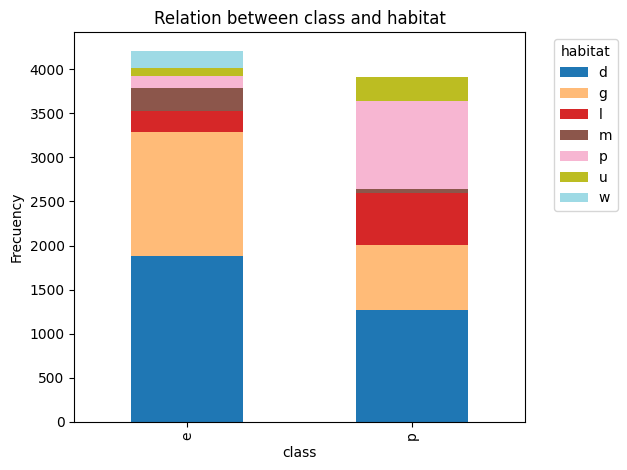

In [41]:
for col in df_decoded.columns:
    if col != 'class':
        crosstab = pd.crosstab(df_decoded['class'], df_decoded[col])
        plt.figure(figsize=(8,5))
        crosstab.plot(kind='bar', stacked=True, colormap='tab20')
        plt.title(f'Relation between class and {col}')
        plt.xlabel('class')
        plt.ylabel('Frecuency')
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()


With those graphics we can know fast if there is any category that only exits in edible or poisonous. For example, in 'ring-number' we can know this column won't be helpful to predict because the distribution between edible and poisonous is very similar. And with 'odor' if it is 'n' (none) it means it is very probably that the mushroom is edible, although there is a probability that isn't.

### 5.3. MULTIVARIABLE ANALYSIS

With numeric variables we use matrix correlation (Pearson), but in this case we use Cramérs' V matrix because the variables are categorical (Chi squared).

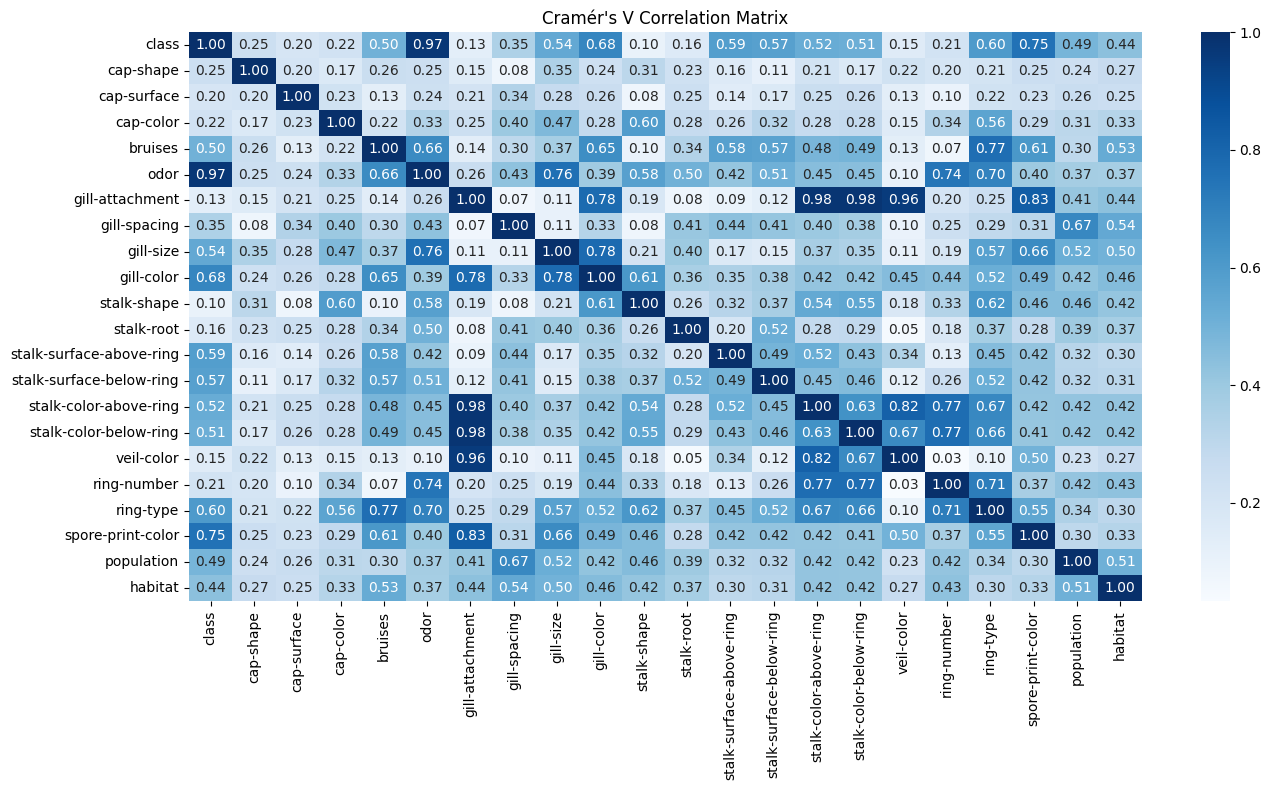

In [23]:
#Cramer's V function
def cramers_v(x, y): #correlation between two columns
    crosstab = pd.crosstab(x, y) #frequency table between two columns (see bivariable analysis)
    chi2 = chi2_contingency(crosstab)[0] #calculate chi-squared
    n = len(x) #rows
    k = min(crosstab.shape) - 1 #number of min categories in the two columns minus one
    return np.sqrt(chi2 / (n * k)) #Cramer's V formula: sqrt(chi2 / (n * k)) (result between 0 and 1))

#Cramer's V matrix
cols = df_decoded.columns
matrix = pd.DataFrame(index=cols, columns=cols, dtype=float) #empty table

for col1 in cols: #it iterates through all combinations
    for col2 in cols:
        matrix.loc[col1, col2] = cramers_v(df_decoded[col1], df_decoded[col2]) #values for the empty table 

plt.figure(figsize=(14, 8))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f', cmap='Blues') #annot=True to show values, fmt='.2f' two decimals
plt.title("Cramér's V Correlation Matrix")
plt.tight_layout()
plt.show()

This matrix goes from 0 (no correlated) to 1 (correlated).

Here we can see easier the things we started to see in the bivariable analysis. The easier example to understand is 'odor'. It has many categories and most of them has a zero in 'edible' or in 'poisonous'. It means this column is highly correlated to class as wee see in the matrix. 

That first column is the most interesting to the prediction, but there are other correlations as 'stalk-color-above-ring' and 'gill-attachment'.

### 5.4. EDA CONCLUSION

'Class' has some correlated variables like 'odor' and 'spore-print-color' that could be helpful to predict 'class'. It also has other like 'cap-shape', 'cap-surface' and 'cap-color' that wuldn't be helpful. 

# 6. MODELS

### 6.1. Split between variables used to predict and the one we want to predict.

In [24]:
y = df_decoded['class'] #target
X = df_decoded.drop('class', axis=1) #features (all columns but 'class')

### 6.2. Encoding from categorical to numerical variables

In [25]:
# One Hot Encoder (one line).
X_encoded = pd.get_dummies(X, drop_first=False)

### 6.3. Train test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.33, random_state=42)

### 6.4. PCA (unsupervised model)

We make a PCA because there are many variable and it helps us to choose the most important variables. This one make cluster per 'class'.

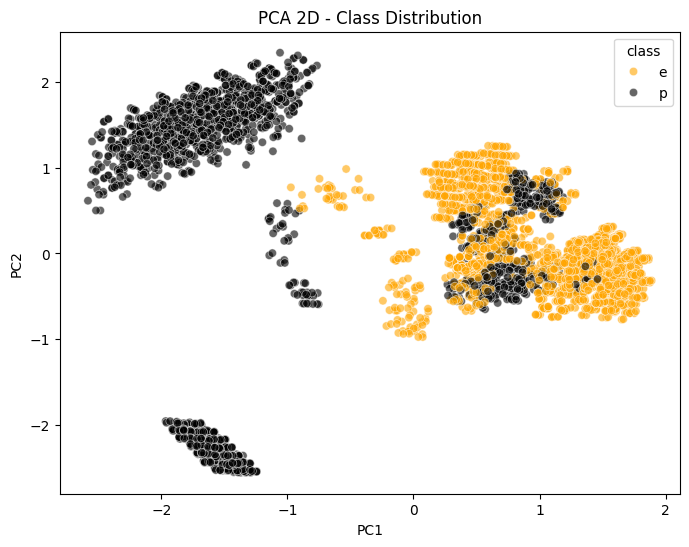

In [27]:
pca = PCA(n_components=2)  
pca.fit(X_train) #training data
X_train_pca = pca.transform(X_train) #trasforming the data

# Scatterplot and tags

df_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
df_pca['class'] = y_train.values #coloring by class

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='class', palette={'e':'orange','p':'black'}, alpha=0.6)
plt.title("PCA 2D - Class Distribution")
plt.show()

### 6.5. RANDOM FOREST CLASSIFIER (supervised model)

We'll compare PCA that is unsupervised to a supervised one like random forest.

In [28]:
# 1. Defining classifier and number of estimators
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# 2. Training on train
rf.fit(X_train, y_train)
# 3. Calculating accuracy on test
y_pred = rf.predict(X_test)
accuracy_nopca = rf.score(X_test, y_test)
print(f"Accuracy: {accuracy_nopca}")

Accuracy: 1.0


It means that all predictions were correct. 0 would mean none were correct.
This accuracy is due to randomforest being a good model and the dataset is not very complex.

In [29]:
print(f"This dataset has {X_train.shape[0]} rows and {X_train.shape[1]} columns")

This dataset has 5443 rows and 115 columns


Here we see how many components would be needed to do the reducing with clusters.

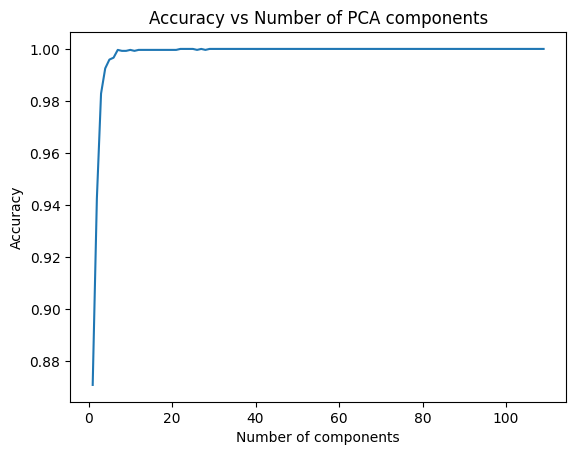

In [ ]:
n_features = range(1,110) # defining a range of values to test
scores = []

for n in n_features:

    # PCA on X_train
    # 1. Defining PCA
    pca = PCA(n_components=n)
    # 2. Fitting (learning) and transforming PCA over X_train
    X_train_pca = pca.fit_transform(X_train) #fit and transform
    X_test_pca = pca.transform(X_test) #only transform

    # Training Random Forest
    # 1. Defining RF
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # 2. Training classifier
    rf.fit(X_train_pca, y_train)
    # Save score
    y_pred = rf.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)
    

sns.lineplot(x=n_features, y=scores)
plt.xlabel('Number of components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of PCA components')
plt.show()

Now, we make zoom to the zone to watch clearly the optimal number of components.

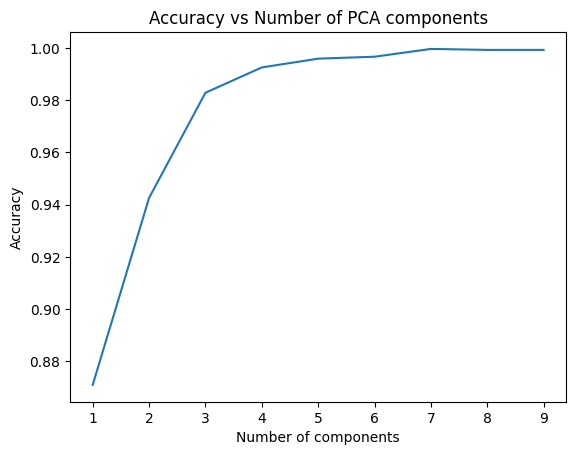

In [ ]:
n_features = range(1,10) # defining a range of values to test
scores = []

for n in n_features:

    # PCA on X_train
    # 1. Defining PCA
    pca = PCA(n_components=n)
    # 2. Fitting (learning) and transforming PCA over X_train
    X_train_pca = pca.fit_transform(X_train) #fit and transform
    X_test_pca = pca.transform(X_test) #only transform

    # Training Random Forest
    # 1. Defining RF
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # 2. Training classifier
    rf.fit(X_train_pca, y_train)
    # Save score
    y_pred = rf.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)

sns.lineplot(x=n_features, y=scores)
plt.xlabel('Number of components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of PCA components')
plt.show()

Here we can see that at 10 features, more or less, we get the accuracy wanted. It is like half of the original variables.

### 6.6. CLUSTERING

We are looking for de optimal number of clusters with the elbow's method.  More on [K-Means on sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

K-means was chosen but other method like aglomerative could have been chosen. It could be done here also to compare both methods.

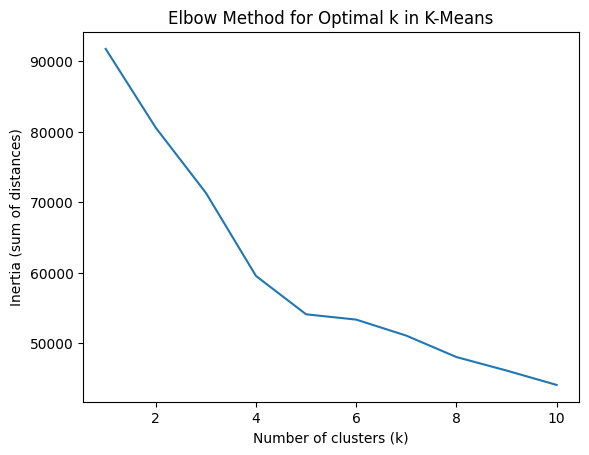

In [46]:
scores = []
k_values = range(1, 11) # defining a range
for a in k_values:

    # Defining Kmeans and fitting
    kmeans = KMeans(n_clusters=a, random_state=42)
    kmeans.fit(X_encoded)
    # Save prediction
    scores.append(kmeans.inertia_)

sns.lineplot(x=k_values, y=scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of distances)")
plt.title("Elbow Method for Optimal k in K-Means")
plt.show()

The optimal k is not cristal clear, but we can see that between 4 and 6 it is when it gets flatter.

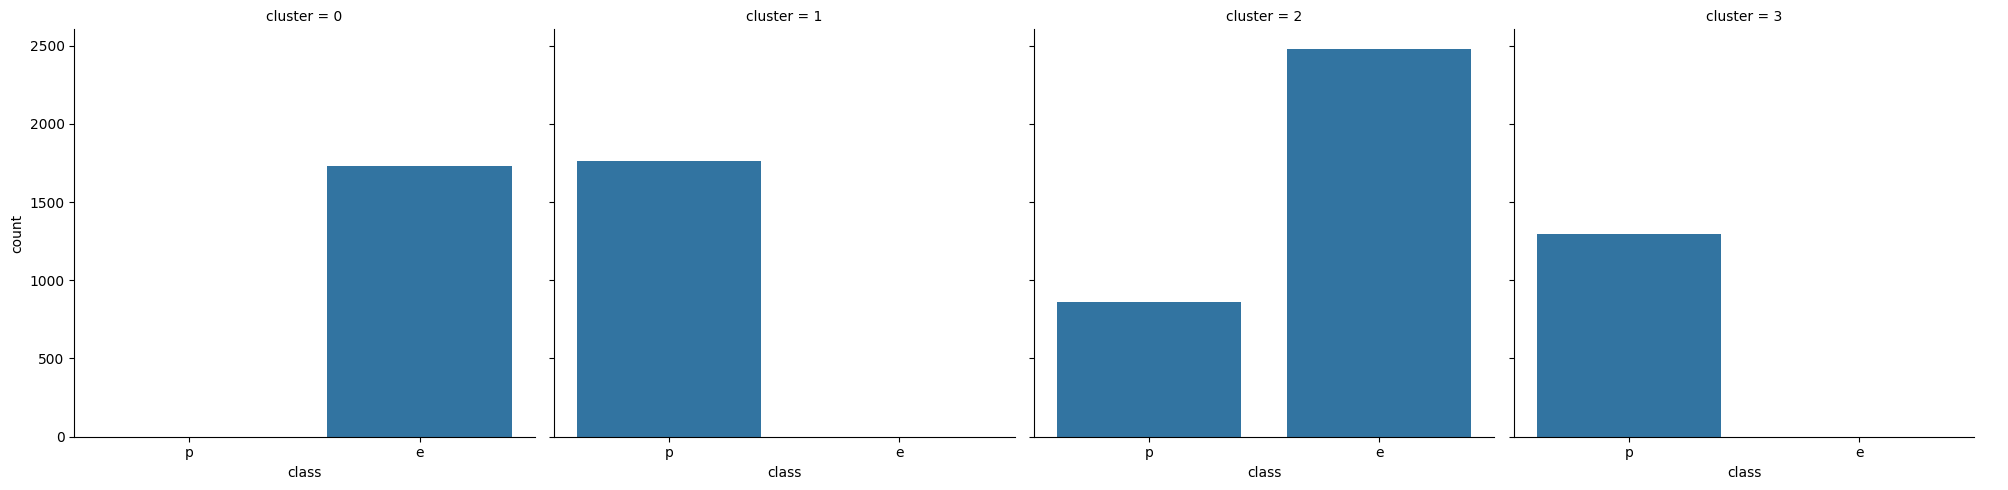

In [47]:
#n_clusters is the optimal k value obtained from the elbow method.
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_encoded)

# DataFrame for catplot.
df_clusters = pd.DataFrame({
    'cluster': clusters,
    'class': y.values
})

# Catplot
ax = sns.catplot(col='cluster', x='class', data=df_clusters, kind='count',col_wrap=4)

This plot means how the clusters are divided, for example, in cluster two most of mushrooms are edible, but some of them are poisonous. Meanwhile the other clusters are only one category. They are edible or poisonous. It means the dataset has patterns and the result is in different clusters.

We'll make now a scatterplot in 2D with the clusters.

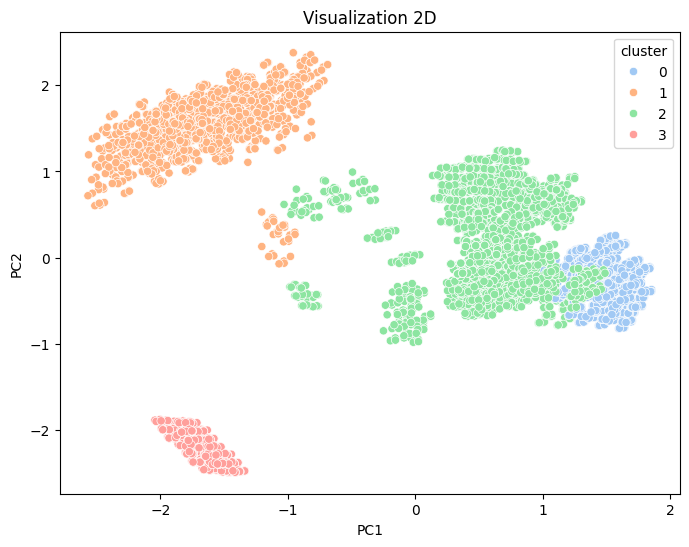

In [48]:
# Train PCA to visualize.
pca_2D = PCA(n_components=2)
X_pca_2D = pca_2D.fit_transform(X_encoded)
# A color per cluster.
df_pca_clusters = pd.DataFrame({
    "PC1": X_pca_2D[:,0],
    "PC2": X_pca_2D[:,1],
    "cluster": clusters  
})

# Scatterplot 
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca_clusters, x="PC1", y="PC2", hue="cluster", palette="pastel")
plt.title("Visualization 2D")
plt.show()

In [49]:
# 1. PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_encoded)

# DataFrame for Plotly
df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['clusters'] = clusters.astype(str)

# 2. 3D interactiva visualization
fig = px.scatter_3d(
    df_pca_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='clusters',
    symbol='clusters',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    title='PCA 3D: Clusters with PC1, PC2 and PC3',
    labels={'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',
            'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
            'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'}
)

fig.update_layout(
    scene_aspectmode='cube',
    width=1000,
    height=700,
    legend=dict(
        x=-0.05,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    margin=dict(r=200) # Aumentar el margen derecho para dar suficiente espacio a la leyenda
)
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.show()

print(f"Variance explained by PC1: {pca_3d.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca_3d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Variance explained by PC3: {pca_3d.explained_variance_ratio_[2]*100:.1f}%")

Variance explained by PC1: 16.2%
Variance explained by PC2: 13.3%
Variance explained by PC3: 9.6%


Those 3 PC explain only about 30% of the variance. The rest would be explained in the other components, but we only can visualize 3 components. 

Now, to know how much would be explain 10 PC:

In [53]:
pca = PCA(n_components=8) 
pca.fit(X_encoded)
print(f'8 components would explain {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance')

8 components would explain 59.15% of the variance


# 7. CONCLUSION IN REDUCING COMPONENTS

We could conclude that using PCA is worthy.

Random Forest without PCA the accuracy is 1.0. 

Random Forest with PCA the accuracy is 0.9993, almost 1.0.

Only 8 components would explain 59% of the variance, it means with only 10 components the model would give an almost perfect accuracy. It also makes it easier to work with.

# 8. EXPORT CSV

In [40]:
df_decoded.to_csv('../data/data_processed/mushrooms_clean.csv', index=False)
print('✅ Clean dataset exported as CSV') #dtypes not preserved

df_decoded.to_parquet('../data/data_processed/mushrooms_clean.parquet', engine='fastparquet', index=False)
print('✅ Clean dataset exported as parquet')

✅ Clean dataset exported as CSV
✅ Clean dataset exported as parquet
